<a href="https://www.kaggle.com/code/kareembasemgoda/cnn-resnet50?scriptVersionId=306787608" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import numpy as np

In [3]:
dataset_dir = '/kaggle/input/plant-disease-recognition-dataset'

image_size = (224, 224)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    subset='training'  
)

valid_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation'  
)



Found 1226 images belonging to 3 classes.
Found 306 images belonging to 3 classes.


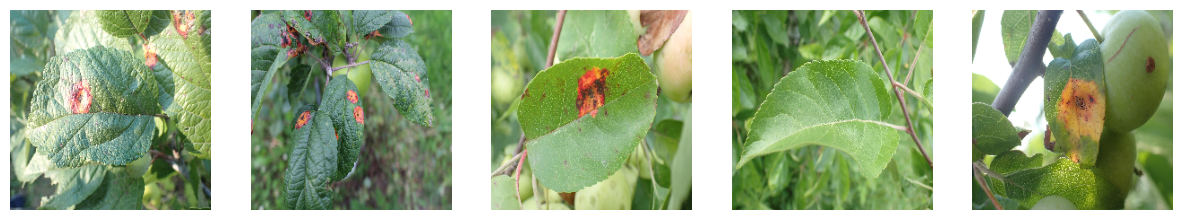

In [13]:
def print_sample_images(generator):
    iterator = iter(generator)
    images, labels = next(iterator)
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for j in range(5):
        axes[j].imshow(images[j])
        axes[j].axis('off')
    plt.show()

print_sample_images(train_gen)


In [5]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)  # Adjust this layer as needed
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [6]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=valid_gen,
)

Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.8634 - loss: 0.5383 - val_accuracy: 0.8627 - val_loss: 0.4842
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8747 - loss: 0.4630 - val_accuracy: 0.8627 - val_loss: 0.4838
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.8523 - loss: 0.5113 - val_accuracy: 0.8627 - val_loss: 0.4880
Epoch 4/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8687 - loss: 0.4743 - val_accuracy: 0.8627 - val_loss: 0.4860
Epoch 5/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8544 - loss: 0.5082 - val_accuracy: 0.8627 - val_loss: 0.4836
Epoch 6/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8622 - loss: 0.4862 - val_accuracy: 0.8627 - val_loss: 0.5018
Epoch 7/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8665 - loss: 0.4805 - val_accuracy: 0.8627 - val_loss: 0.4962
Epoch 8/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8664 - loss: 0.4820 - val_accuracy: 0.8627 - val_loss

In [8]:
val_loss, val_accuracy = model.evaluate(valid_gen)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8413 - loss: 0.5349
Validation Accuracy: 86.27%


In [9]:
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 86.27%


In [10]:
model.save('resnet50_model.h5') 